# Yelp AHA Record Linkage
* Link AHA hospitals (names and addresses) with Yelp facilities

In [51]:
import fuzzymatcher
import recordlinkage
import jenkspy

import pandas as pd
import math
import numpy as np
import scipy as sp

import re
import os
import sys
import datetime
import glob
from pprint import pprint

import pyLDAvis
import pyLDAvis.gensim
import matplotlib.pyplot as plt
import seaborn as sns

sns.set()
%matplotlib inline

pd.set_option('display.max_columns',100)
pd.set_option('display.max_rows',200)
pd.set_option('display.precision',4)

## Program Parameters

### Constants

In [2]:
MAX_ATTEMPTS = 100

### Paths

In [3]:
#### Fixed Paths ####

BASE_PATH = '/' # replace as needed
DATA_PATH = BASE_PATH + 'data/'
CODE_PATH = BASE_PATH + 'code/'
ANALYSIS_PATH = BASE_PATH + 'analysis/'

## Function Definitions

## Read Data

### Yelp Data

In [4]:
# Get date string
count=0
use_date = datetime.datetime.now().date()
date_str_fmt = str(use_date)
date_str = date_str_fmt.replace('-','')

while not any(date_str in item for item in glob.glob(DATA_PATH + '*')) or count==MAX_ATTEMPTS:
    use_date = use_date - pd.to_timedelta(1, unit='days')
    date_str_fmt = str(use_date)
    date_str = date_str_fmt.replace('-','')
    
    count+=1
    if count == MAX_ATTEMPTS:
        print('Could not find any data!')
        break

In [ ]:
# Base data
reviews = pd.read_csv(DATA_PATH + date_str + '_reviews.csv', index_col=0)
facilities = pd.read_csv(DATA_PATH + date_str + '_facilities.csv', index_col=0)
categories = pd.read_csv(DATA_PATH + date_str + '_categories.csv', index_col=0)

In [6]:
# clean data
reviews = reviews[~(reviews['fac_id'].isin(['HH N.','Suhas V.']))]
reviews = reviews.dropna(subset=['review','rev_rating'])
# Adjust columns
reviews['review'] = reviews['review'].fillna('')
reviews['review'] = reviews['review'].str.lower()
reviews['rev_rating'] = reviews['rev_rating'].astype('int32')
reviews['rev_created_time'] = pd.to_datetime(reviews['rev_created_time'])

### AHA / Fips Data

In [7]:
# Fips codes
fips = pd.read_csv(DATA_PATH + 'fips_codes_2018.csv')

# States
exclude_cols = ['county_code','county_subdivision_code','place_code','consolidated_city_code']
states = fips[(fips[exclude_cols]==0).all(axis=1)].iloc[1:,:]
states_dict = dict(zip(states['state_code'],states['area_name']))

# Counties
exclude_cols = ['county_subdivision_code','place_code','consolidated_city_code']
counties = fips[(fips[exclude_cols]==0).all(axis=1) & (fips['county_code']!=0)]
counties_dict = dict(zip(counties['county_code'],counties['area_name']))

In [8]:
# AHA data
aha = pd.read_csv(DATA_PATH + 'aha_data.csv',encoding='latin')
aha = aha[aha['YEAR']==2018]
aha = aha[aha['FSTCD'].isin(fips['state_code'])]
aha['STATE'] = [item[1].strip() for item in aha.CNTYNAME.str.split(',')]

### Display Data

In [9]:
print(len(facilities))
facilities.head(2)

516699


,fac_id,fac_name,fac_is_closed,review_count,fac_rating,fac_updated_time,phone,business_url,fac_url,address,city,state,country,postal_code,latitude,longitude
0,drsGMLVzqRGoVnqeF5ynUg,"Adam Nowlan, MD, MPH",False,1,5.0,2019-06-18T15:23:22,1.4046e+10,http://www.atlantaradiationoncology.com,https://www.yelp.com/biz/adam-nowlan-md-mph-at...,1968 Peachtree Rd NW,Atlanta,GA,US,3.031e+04,NaN,NaN
1,BKHtvH2kGWTBiPWu_jtPLg,The Healing Hand Massage,False,1,4.0,2020-02-28T09:32:50,1.3365e+10,http://www.thehealinghand.co,https://www.yelp.com/biz/the-healing-hand-mass...,4911 Archdale Rd Ste J,Archdale,NC,US,2.726e+04,35.8869,-79.959


In [10]:
print(len(fips))
fips.head(2)

43847


,summary_level,state_code,county_code,county_subdivision_code,place_code,consolidated_city_code,area_name
0,10,0,0,0,0,0,United States
1,40,1,0,0,0,0,Alabama


In [11]:
print(len(aha))
aha.head(2)

6210


,ID,STCD,DTBEG,DTEND,YEAR,CNTYNAME,MNAME,MLOCADDR,MLOCCITY,GRACE,MLOCSTCD,MCNTYCD,FCOUNTY,FSTCD,FCNTYCD,MLOCZIP,STATE
5,6040001,4,NaN,NaN,2018,"Vega Baja, PR",Wilma N. Vazquez Medical Center,"KM 39 1/2 Road 2, Call Box 7001",Vega Baja,NaN,4,145,72145,72,145,00694,PR
8,6040002,4,NaN,NaN,2018,"San Juan, PR",Hospital San Francisco,371 Avenida De Diego,San Juan,NaN,4,127,72127,72,127,00923-1711,PR


## Fuzzy Matching

In [12]:
# aha
left_on = ['MNAME','MLOCADDR','MLOCCITY','STATE']
for col in left_on:
    aha[col] = aha[col].str.lower()
    aha[col] = aha[col].str.strip()

# facilities
right_on = ['fac_name','address','city','state']
for col in right_on:
    facilities[col] = facilities[col].str.lower()
    facilities[col] = facilities[col].str.strip()

In [13]:
matched_results = fuzzymatcher.fuzzy_left_join(aha,facilities,left_on,right_on,left_id_col='ID',right_id_col='fac_id')
matched_results.to_csv(DATA_PATH + 'aha_yelp_matched_' + str(datetime.datetime.now().date()).replace('-','') + '.csv')

Text(0.5201849336590101, 600, '0.5202')

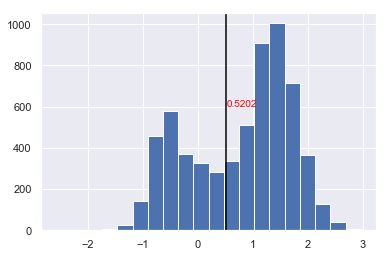

In [63]:
breaks = jenkspy.jenks_breaks(matched_results.best_match_score, nb_class=2)
ax = matched_results.best_match_score.hist(bins=20)
ax.axvline(breaks[1], color='black')
ax.text(breaks[1],600,str(round(breaks[1],4)),color='red')

In [67]:
matched_clean = matched_results[left_on+right_on+['best_match_score','__id_left','__id_right']].sort_values('best_match_score',ascending=False)
matched_clean = matched_clean[matched_clean['best_match_score']>=0.5]

In [68]:
print(len(matched_clean))
matched_clean.head()

3999


,MNAME,MLOCADDR,MLOCCITY,STATE,fac_name,address,city,state,best_match_score,__id_left,__id_right
43055,new york eye and ear infirmary of mount sinai,310 east 14th street,new york,ny,new york eye and ear infirmary of mount sinai,310 east 14th street,new york,ny,2.9642,6213190,Em4xpgBOFKu6neFbAH1cvg
231513,mercyhealth hospital and medical center - walw...,n2950 state road 67,lake geneva,wi,mercyhealth walworth hospital and medical cent...,n2950 state rd 67,lake geneva,wi,2.9115,6450038,wPJiE2tupxCpmxeDvgQjrw
597285,multicare tacoma general hospital,315 martin luther king jr way,tacoma,wa,multicare tacoma general hospital,315 martin luther king jr way,tacoma,wa,2.9029,6911018,NfQhouuNZwwtPHMa_eyWdA
201702,captain james a. lovell federal health care ce...,3001 green bay road,north chicago,il,captain james a lovell federal health care center,3001 green bay rd,north chicago,il,2.8607,6431480,o_lB-tcYBV1UzJcF6qjKfA
320646,sanford medical center thief river falls,3001 sanford parkway,thief river falls,mn,sanford thief river falls medical center,3001 sanford pkwy,thief river falls,mn,2.7502,6611860,ozn3lL8-v_lu5LqCemFhkw


In [69]:
matched_clean.tail()

,MNAME,MLOCADDR,MLOCCITY,STATE,fac_name,address,city,state,best_match_score,__id_left,__id_right
617354,huntington memorial hospital,100 west california boulevard,pasadena,ca,huntington hospital,100 w california blvd,pasadena,ca,0.5042,6932350,wl4L3dxLbkMiQ7qf19Bexw
142293,centerstone hospital,2020 26th avenue east,bradenton,fl,centerstone behavioral hospital and addiction ...,2020 26th ave e,bradenton,fl,0.5031,6390112,uXJ9kabwn-k9IEUaAKK_-Q
157417,select specialty hospital - cincinnati north,10500 montgomery road,cincinnati,oh,trihealth bethesda north hospital,10500 montgomery rd,cincinnati,oh,0.5029,6410045,uIiZV4j-9vy89CM5AeQbNw
584322,the orthopedic specialty hospital,5848 south 300 east,murray,ut,the orthopedic specialty hospital,5848 fashion blvd,salt lake city,ut,0.5014,6870008,ffXHST8VWuj8Huxy89NHIg
100804,princeton community hospital,122 12th street,princeton,wv,princeton community hospital,12 st,princeton,wv,0.5013,6350642,QPCJHZ5tGvAcEmJPz-Q4ig
